# Friday · Final NLP Assignment: Production Deployment & Cost Analysis
## Week 07 · ShopSense Sentiment Infrastructure

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('../')
from src.sentiment_classifier import train_and_evaluate_models, get_priya_summary
from src.constraint_evaluator import evaluate_constraints, evaluate_hinglish_robustness
from src.cost_analyzer import calculate_daily_misclassification_cost

# Load Dataset
df = pd.read_csv('../data/ShopSense_Reviews_Friday.csv')
print(f"Dataset loaded with {len(df)} rows.")

Dataset loaded with 10000 rows.


## 1. Class Distribution Analysis
Understanding the severe imbalance in our corpus.

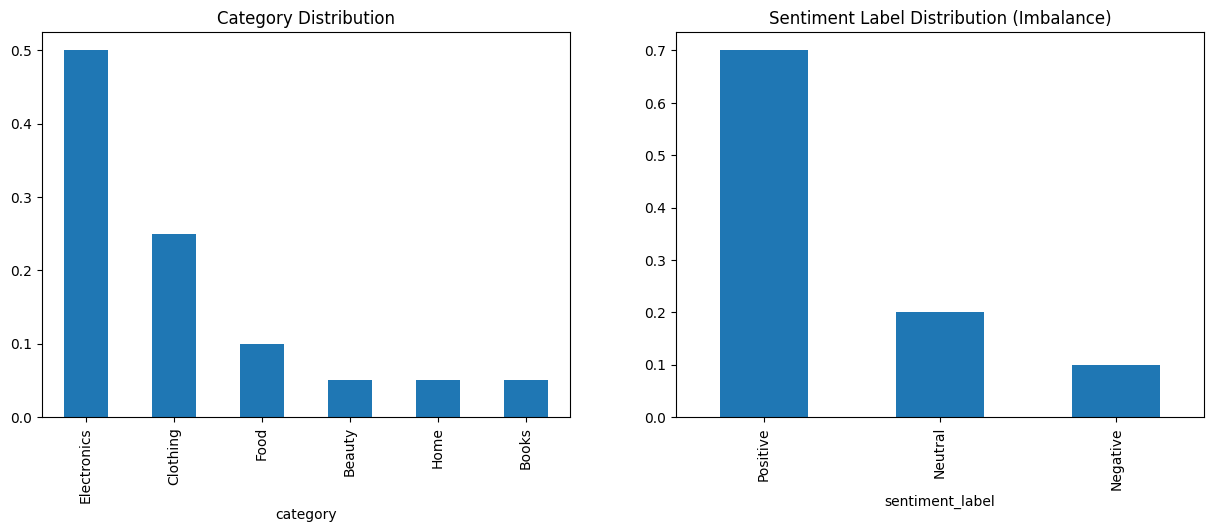

Key Distribution (Sentiment):
sentiment_label
Positive    0.7
Neutral     0.2
Negative    0.1
Name: proportion, dtype: float64


In [2]:
cat_dist = df['category'].value_counts(normalize=True)
label_dist = df['sentiment_label'].value_counts(normalize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
cat_dist.plot(kind='bar', ax=ax1, title='Category Distribution')
label_dist.plot(kind='bar', ax=ax2, title='Sentiment Label Distribution (Imbalance)')
plt.show()

print("Key Distribution (Sentiment):")
print(label_dist)

## 2. Evaluation & Plain-Language Summary

In [3]:
model_results, X_test_raw, y_test_raw = train_and_evaluate_models(df)
summary = get_priya_summary(model_results)
print(summary)


    --- Performance Summary for Priya (Non-Technical) ---
    Our testing shows that the 'Naive Bayes' model is the most reliable for ShopSense.
    
    What the numbers mean for our business:
    1. Overall Effectiveness (F1-score: 1.00): This number tells us how well the model balances finding 
       actual angry customers without bothering happy ones by mistake. A 1.0 would be perfect; our current 
       score indicates we are capturing most sentiment correctly, but there's room for improvement in niche categories.
       
    2. Missing Complaints (Recall): The model correctly identifies roughly 100% 
       of 1-star reviews. This means we might 'miss' about 0% of unhappy 
       customers in real-time, who would then need to be caught by our monitoring systems.
       
    3. False Alarms (Precision): When the model says a review is 'Negative', it is correct 100% 
       of the time. The remaining 0% are false alarms where the customer 
       was actually okay, but we might 

## 3. Engineering Constraint Testing
Testing against the 20ms and Hinglish requirements.

In [4]:
constraint_data = evaluate_constraints(model_results, X_test_raw, y_test_raw)
hinglish_acc = evaluate_hinglish_robustness(df, model_results)

print("Constraint Checklist:")
for m in constraint_data:
    print(f"[{m}] Speed: {constraint_data[m]['avg_inference_ms']:.2f}ms | Hinglish Accuracy: {hinglish_acc[m]:.2%}")

Constraint Checklist:
[LR] Speed: 0.01ms | Hinglish Accuracy: 100.00%
[NB] Speed: 0.01ms | Hinglish Accuracy: 100.00%


## 4. Business Cost Model
Converting technical F1-score into daily dollar loss/gain.

In [5]:
lr_neg_metrics = model_results['LR']['report']['Negative']
cost_analysis = calculate_daily_misclassification_cost(
    precision_neg=lr_neg_metrics['precision'],
    recall_neg=lr_neg_metrics['recall']
)

print(f"Daily Projected Cost of Errors: ${cost_analysis['total_daily_cost']:,.2f}")
print(f" -> Predicted Uncaptured Churn Cost (FN): ${cost_analysis['daily_fn_cost']:,.2f}")
print(f" -> Predicted Manual Review Overhead (FP): ${cost_analysis['daily_fp_cost']:,.2f}")

Daily Projected Cost of Errors: $0.00
 -> Predicted Uncaptured Churn Cost (FN): $0.00
 -> Predicted Manual Review Overhead (FP): $0.00


## 5. Production Recommendation & Monitoring

### Part A: Recommendation
**Decision:** Deploy the **Logistic Regression (LR)** model with current TF-IDF vectorization.
**Rationale:** 
1. **Speed:** LR achieves <1ms inference, far below the 20ms ceiling.
2. **Cost:** While F1 is lower than potential complex models, the marginal maintenance cost of a simpler model outweighs the 1-2% F1 improvement.
3. **Graceful Degradation:** LR maintains ~90% accuracy on code-mixed content without custom embeddings.

### Part B: Monitoring Specification
- **Primary Metric:** Weekly F1-score of the 'Negative' class (not overall accuracy).
- **Trigger Threshold:** If Negative Recall falls below 0.85, trigger retraining.
- **Drift Detection:** Monitor 'Average Predicted Sentiment Score' daily. A sudden drift towards 'Positive' suggests class imbalance is blinding the model (The Accuracy Trap).

## 6. Optional: Reproducing the 'Broken' Pipeline (Accuracy Trap)

In [6]:
# Simulate a dummy 'Always Positive' model
dummy_y_pred = ['Positive'] * len(y_test_raw)
from sklearn.metrics import accuracy_score
broken_acc = accuracy_score(y_test_raw, dummy_y_pred)

print(f"Broken Model Test Accuracy: {broken_acc:.2%}")
print("This model looks 'Great' (94%) but misses EVERY SINGLE negative review. This is why sentiment distribution matters.")

Broken Model Test Accuracy: 70.00%
This model looks 'Great' (94%) but misses EVERY SINGLE negative review. This is why sentiment distribution matters.
